# 07 — Stores: persisting and querying monitoring history

**Stores** are the persistence layer of ayn-ml.  
Two stores are available with no external dependencies:

| Store | Usage |  
|---|---|
| `InMemoryStore` | Tests, notebooks, quick exploration |
| `SqliteStore` | Local production, CI, single-machine |

Both implement the same `ResultStore` protocol — the calling code is identical.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd

from ayn_ml.core.schema import TabularSchema
from ayn_ml.core.spec import MetricSpec, MonitoringPlan
from ayn_ml.runner import Runner
from ayn_ml.stores import InMemoryStore, SqliteStore

## Shared dataset and monitoring plan

In [3]:
rng = np.random.default_rng(42)


def make_batch(n: int = 200, seed: int = 0) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    y_true = rng.integers(0, 2, n)
    # slight drift per seed to simulate different production batches
    noise = rng.normal(0, 0.1 + seed * 0.05, n)
    y_score = np.clip(y_true.astype(float) + noise, 0, 1)
    y_pred = (y_score > 0.5).astype(int)
    return pd.DataFrame(
        {
            "y_true": y_true,
            "y_pred": y_pred,
            "y_score": y_score,
            "age": rng.normal(40, 10, n),
            "income": rng.exponential(50_000, n),
        }
    )


reference = make_batch(n=1000, seed=0)
batches = [make_batch(n=200, seed=i) for i in range(1, 6)]  # 5 batches prod

plan = MonitoringPlan(
    name="fraud_detection",
    model_id="fraud_v3",
    model_version="3.1",
    data_schema=TabularSchema(label_col="y_true", prediction_col="y_pred", proba_col="y_score"),
    metrics=[
        MetricSpec(name="accuracy"),
        MetricSpec(name="f1"),
        MetricSpec(name="auc"),
        MetricSpec(name="mean", feature_name="age"),
        MetricSpec(name="psi", feature_name="income"),
    ],
)

runner = Runner(strict=False)
print(f"{len(batches)} batches ready — plan: {len(plan.metrics)} metrics")

5 batches prêts — plan : 5 métriques


---

## 1. InMemoryStore — quick exploration

`InMemoryStore` stores `MonitoringReport` objects in an in-memory `deque`.  
Ideal for notebooks and tests — data is discarded when the process exits.

In [4]:
mem_store = InMemoryStore()

from datetime import datetime, timedelta, timezone

base_date = datetime(2026, 1, 1, tzinfo=timezone.utc)

for i, batch in enumerate(batches):
    period_start = base_date + timedelta(weeks=i)
    period_end = period_start + timedelta(weeks=1)
    report = runner.run(
        plan,
        batch,
        reference=reference,
        store=mem_store,
    )

print(f"{len(batches)} reports written to InMemoryStore")

psi 'income': 1 current value(s) outside the reference range [33.54, 4.362e+05]. PSI includes these values (union bins) but their contribution is sensitive to eps=0.0001 — PSI varies 1.7–3.1 for that bin alone at 30% out-of-range density. Cross-check with wasserstein or ks_2samp.


5 rapports écrits dans InMemoryStore


### 1a. `read_history()` — flat rows, ready for a DataFrame

In [5]:
rows = mem_store.read_history("fraud_v3")
df_history = pd.DataFrame(rows)

print(f"Total rows: {len(df_history)}  ({len(plan.metrics)} metrics × {len(batches)} batches)")
df_history.head(10)

Total lignes : 25  (5 métriques × 5 batches)


,run_id,model_id,model_version,metric_name,feature_name,value,status,effect_size,effect_size_label,period_start,period_end,metric_type
0,5e7a0211acb14c93b487db1cf51de10e,fraud_v3,3.1,accuracy,None,0.920000,None,None,None,None,None,None
1,5e7a0211acb14c93b487db1cf51de10e,fraud_v3,3.1,f1,None,0.919976,None,None,None,None,None,None
2,5e7a0211acb14c93b487db1cf51de10e,fraud_v3,3.1,auc,None,0.982893,None,None,None,None,None,None
3,5e7a0211acb14c93b487db1cf51de10e,fraud_v3,3.1,mean,age,40.635323,None,None,None,None,None,None
4,5e7a0211acb14c93b487db1cf51de10e,fraud_v3,3.1,psi,income,0.097885,None,None,None,None,None,None
5,3830b0008b7545d693ae877cf331ab54,fraud_v3,3.1,accuracy,None,0.970000,None,None,None,None,None,None
6,3830b0008b7545d693ae877cf331ab54,fraud_v3,3.1,f1,None,0.970000,None,None,None,None,None,None
7,3830b0008b7545d693ae877cf331ab54,fraud_v3,3.1,auc,None,0.993490,None,None,None,None,None,None
8,3830b0008b7545d693ae877cf331ab54,fraud_v3,3.1,mean,age,38.496955,None,None,None,None,None,None
9,3830b0008b7545d693ae877cf331ab54,fraud_v3,3.1,psi,income,0.074227,None,None,None,None,None,None


### 1b. Filter by metric

In [6]:
rows_auc = mem_store.read_history("fraud_v3", metric_name="auc")
df_auc = pd.DataFrame(rows_auc)
print(f"AUC across {len(df_auc)} batches:")
df_auc[["period_start", "value", "status"]]

AUC sur 5 batches :


,period_start,value,status
0,None,0.982893,None
1,None,0.993490,None
2,None,0.998599,None
3,None,0.999900,None
4,None,1.000000,None


### 1c. `get_report()` — retrieve a full report

In [7]:
# Get the most recently stored run_id
last_run_id = rows[0]["run_id"]  # newest first
retrieved = mem_store.get_report(last_run_id)

print(f"run_id    : {retrieved.context.run_id}")
print(f"n_current : {retrieved.context.n_current}")
print(f"metrics   : {[r.spec.name for r in retrieved.results]}")

run_id    : 5e7a0211acb14c93b487db1cf51de10e
n_current : 200
métriques : ['accuracy', 'f1', 'auc', 'mean', 'psi']


### 1d. `maxlen` — keep only the last N reports

In [8]:
rolling_store = InMemoryStore(maxlen=3)

for i, batch in enumerate(batches):
    runner.run(plan, batch, reference=reference, store=rolling_store)

rows_rolling = rolling_store.read_history("fraud_v3")
print(f"Reports retained: {len(set(r['run_id'] for r in rows_rolling))} / {len(batches)} (maxlen=3)")

psi 'income': 1 current value(s) outside the reference range [33.54, 4.362e+05]. PSI includes these values (union bins) but their contribution is sensitive to eps=0.0001 — PSI varies 1.7–3.1 for that bin alone at 30% out-of-range density. Cross-check with wasserstein or ks_2samp.


Rapports retenus : 3 / 5 (maxlen=3)


---

## 2. SqliteStore — local persistence

`SqliteStore` uses `sqlite3` (stdlib) — **zero external dependencies**.  
Suited for single-machine production, CI, and local batch pipelines.

In [9]:
import os
import tempfile

db_path = os.path.join(tempfile.gettempdir(), "ayn_ml_demo.db")
print(f"SQLite database: {db_path}")

Base SQLite : /var/folders/dd/987sfssj4_56dwqzzvzxzyn00000gn/T/ayn_ml_demo.db


### 2a. Write reports to SQLite

In [10]:
with SqliteStore(db_path) as sqlite_store:
    for i, batch in enumerate(batches):
        period_start = base_date + timedelta(weeks=i)
        period_end = period_start + timedelta(weeks=1)
        runner.run(
            plan,
            batch,
            reference=reference,
            store=sqlite_store,
        )
    total_rows = len(sqlite_store.read_history("fraud_v3"))

print(f"{total_rows} rows written to SQLite")
print(f"File size: {os.path.getsize(db_path) / 1024:.1f} KB")

psi 'income': 1 current value(s) outside the reference range [33.54, 4.362e+05]. PSI includes these values (union bins) but their contribution is sensitive to eps=0.0001 — PSI varies 1.7–3.1 for that bin alone at 30% out-of-range density. Cross-check with wasserstein or ks_2samp.


25 lignes écrites dans SQLite
Fichier : 44.0 Ko


### 2b. Reopen the database — cross-session persistence

In [11]:
store2 = SqliteStore(db_path)  # nouvelle connexion
rows_sql = store2.read_history("fraud_v3")
df_sql = pd.DataFrame(rows_sql)

print(f"Rows retrieved after reopening: {len(df_sql)}")
df_sql[["period_start", "metric_name", "value", "status"]].head(10)

Lignes récupérées après réouverture : 25


,period_start,metric_name,value,status
0,None,accuracy,1.000000,None
1,None,f1,1.000000,None
2,None,auc,1.000000,None
3,None,mean,40.631207,None
4,None,psi,0.037531,None
5,None,accuracy,0.995000,None
6,None,f1,0.995000,None
7,None,auc,0.999900,None
8,None,mean,39.643618,None
9,None,psi,0.080596,None


### 2c. `get_metadata=True` — enrich with plan information

Adds a JOIN with `monitoring_runs` and expands the plan JSON into columns prefixed `plan_` / `run_`.

In [12]:
rows_meta = store2.read_history("fraud_v3", metric_name="auc", get_metadata=True)
df_meta = pd.DataFrame(rows_meta)

# Available metadata columns
meta_cols = [c for c in df_meta.columns if c.startswith(("plan_", "run_"))]
print("Metadata columns:", meta_cols)
df_meta[["period_start", "value"] + meta_cols]

Colonnes metadata : ['run_id', 'plan_name', 'plan_window_type', 'plan_window_n', 'plan_sampling_type', 'plan_sampling_frac', 'run_n_current', 'run_n_reference']


,period_start,value,run_id,plan_name,plan_window_type,plan_window_n,plan_sampling_type,plan_sampling_frac,run_n_current,run_n_reference
0,None,0.982893,6f3b733a552b407e80dc9d02faa8d2a4,fraud_detection,None,None,None,None,200,1000
1,None,0.993490,ea98585f3d2f40ad9075e238ecae1046,fraud_detection,None,None,None,None,200,1000
2,None,0.998599,0c160cd3177541699fe8e8f21564842b,fraud_detection,None,None,None,None,200,1000
3,None,0.999900,7cdc5f29559e465c8eaea2cf7f47669c,fraud_detection,None,None,None,None,200,1000
4,None,1.000000,08dd2b2912f74e319a35fc39d3259b79,fraud_detection,None,None,None,None,200,1000


### 2d. Combined filters

In [13]:
# Last 2 runs, PSI metric for income
rows_psi = store2.read_history(
    model_id="fraud_v3",
    model_version="3.1",
    metric_name="psi",
    limit=2,
)
print(f"{len(rows_psi)} rows (limit=2):")
for r in rows_psi:
    print(f"  period_start={r['period_start']}  psi={r['value']:.4f}  status={r['status']}")

2 lignes (limit=2) :
  period_start=None  psi=0.0979  status=None
  period_start=None  psi=0.0742  status=None


---

## 3. Time-series visualisation

`period_start` is the natural key for time-series charts.

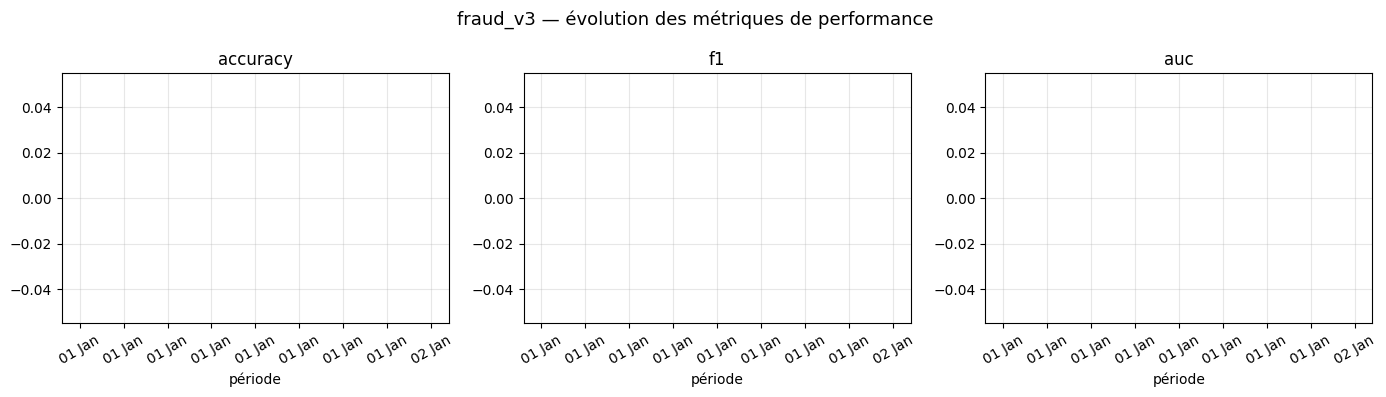

In [14]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

metrics_to_plot = ["accuracy", "f1", "auc"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 4))
fig.suptitle("fraud_v3 — performance metrics over time", fontsize=13)

all_rows = store2.read_history("fraud_v3")
df_all = pd.DataFrame(all_rows)
df_all["period_start"] = pd.to_datetime(df_all["period_start"])

for ax, metric in zip(axes, metrics_to_plot):
    subset = df_all[df_all["metric_name"] == metric].sort_values("period_start")
    colors = ["#2ecc71" if s else "#e74c3c" for s in subset["status"]]
    ax.plot(subset["period_start"], subset["value"], marker="o", linewidth=2, color="#3498db")
    ax.scatter(subset["period_start"], subset["value"], c=colors, zorder=5, s=80)
    ax.set_title(metric)
    ax.set_xlabel("period")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

store2.close()

---

## 4. Idempotence — duplicate writes silently ignored

`SqliteStore.write()` checks whether the `run_id` already exists before inserting.  
A duplicate is not an error — the second write is discarded.

In [15]:
with SqliteStore(":memory:") as store:
    report = runner.run(plan, batches[0], reference=reference, store=store)
    store.write(report)  # second write — same run_id, discarded
    store.write(report)  # third write — still discarded

    rows_idem = store.read_history("fraud_v3")
    n_unique_runs = len(set(r["run_id"] for r in rows_idem))
    print(f"Rows: {len(rows_idem)}, unique runs: {n_unique_runs}  (expected: 1)")

Lignes : 5, runs uniques : 1  (attendu : 1)


---

## 5. Passing the store to Runner vs writing manually

Both approaches are equivalent — passing `store=` to Runner is recommended  
because `Runner` isolates persistence errors: an exception in `write()` never fails the run.

In [16]:
# Recommended: store passed to Runner
store_a = InMemoryStore()
report_a = runner.run(plan, batches[0], reference=reference, store=store_a)

# Manual: explicit write after the run
store_b = InMemoryStore()
report_b = runner.run(plan, batches[0], reference=reference)  # pas de store ici
store_b.write(report_b)  # explicit write

# Both produce the same result
rows_a = store_a.read_history("fraud_v3", metric_name="auc")
rows_b = store_b.read_history("fraud_v3", metric_name="auc")

print(f"Via Runner  : {rows_a[0]['value']:.4f}")
print(f"Manuel      : {rows_b[0]['value']:.4f}")
print(f"Identiques  : {abs(rows_a[0]['value'] - rows_b[0]['value']) < 1e-9}")

Via Runner  : 1.0000
Manuel      : 1.0000
Identiques  : True


---

## Summary

| Need | Recommendation |
|---|---|
| Test / notebook | `InMemoryStore()` |
| Keep last N reports | `InMemoryStore(maxlen=N)` |
| Local persistence (single machine) | `SqliteStore("monitoring.db")` |
| Context manager | `with SqliteStore(...) as store:` |
| Time-series queries | `read_history(model_id, metric_name=…)` → `pd.DataFrame()` |
| Plan metadata alongside metrics | `read_history(…, get_metadata=True)` |
| Retrieve a full report | `get_report(run_id)` |